# LAB03 · Ensambles, reducción dimensional y Green AI

**Continuación del Ejercicio 01.** Mismo dataset (German Credit), mismo target (`class`) y misma partición aprobada.

**Objetivo:** Comparar SVM, Random Forest y Boosting bajo un protocolo común, evaluar reducción dimensional (PCA, t-SNE) y tomar una decisión informada mediante la frontera de Pareto.

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/raw/dataset.csv")
TARGET = "class"
X = df.drop(columns=[TARGET])
y = df[TARGET]

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scale", StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                     ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocess = ColumnTransformer([("num", num_pipe, num_cols),
                                ("cat", cat_pipe, cat_cols)])

Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(Xtr.shape, Xte.shape)

(800, 20) (200, 20)


In [2]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {
 "logistic": Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=2000))]),
 "svm_c1": Pipeline([("prep", preprocess), ("model", SVC(C=1, class_weight="balanced", probability=True, random_state=42))]),
 "svm_c10": Pipeline([("prep", preprocess), ("model", SVC(C=10, class_weight="balanced", probability=True, random_state=42))]),
 "rf_100": Pipeline([("prep", preprocess), ("model", RandomForestClassifier(n_estimators=100, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1))]),
 "rf_300": Pipeline([("prep", preprocess), ("model", RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1))]),
 "boost": Pipeline([("prep", preprocess), ("model", HistGradientBoostingClassifier(max_depth=6, random_state=42))])
}
print(list(models.keys()))

['logistic', 'svm_c1', 'svm_c10', 'rf_100', 'rf_300', 'boost']


In [3]:
from time import perf_counter
from pathlib import Path
import joblib, numpy as np
from sklearn.metrics import f1_score, recall_score

Path("../reports/models").mkdir(parents=True, exist_ok=True)
rows = []
for name, model in models.items():
    fit_times = []
    for repetition in range(3):
        start = perf_counter()
        model.fit(Xtr, ytr)
        fit_times.append(perf_counter() - start)
    start = perf_counter()
    pred = model.predict(Xte)
    predict_ms = (perf_counter() - start) * 1000
    path = Path("../reports/models") / f"{name}.joblib"
    joblib.dump(model, path)
    rows.append({
        "model": name,
        "f1_macro": f1_score(yte, pred, average="macro"),
        "recall_macro": recall_score(yte, pred, average="macro"),
        "fit_median_s": np.median(fit_times),
        "predict_ms": predict_ms,
        "size_kb": path.stat().st_size / 1024
    })

results = pd.DataFrame(rows)
results.sort_values("f1_macro", ascending=False)

c:\Users\PC\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\PC\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\PC\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\PC\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed i

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb
1,svm_c1,0.736264,0.761905,1.382955,176.5800,305.427734
2,svm_c10,0.726545,0.732143,1.992890,121.3018,281.099609
0,logistic,0.720954,0.709524,0.250068,54.1653,7.916016
4,rf_300,0.696794,0.717857,3.165966,407.5032,3864.073242
5,boost,0.688150,0.676190,1.770301,56.5967,209.814453
3,rf_100,0.674743,0.694048,1.200619,216.4370,1315.948242


In [4]:
from sklearn.decomposition import PCA

# PCA necesita datos numéricos densos — aplicamos el preprocesamiento primero
X_processed_train = preprocess.fit_transform(Xtr)
X_processed_test = preprocess.transform(Xte)
print("Dimensiones originales tras preprocesamiento:", X_processed_train.shape)

pca = PCA(n_components=0.95, random_state=42)
X_pca_train = pca.fit_transform(X_processed_train)
print("Componentes retenidos (95% varianza):", pca.n_components_)

svm_pca = Pipeline([("model", SVC(C=1, class_weight="balanced", probability=True, random_state=42))])
svm_pca.fit(X_pca_train, ytr)
X_pca_test = pca.transform(X_processed_test)
pred_pca = svm_pca.predict(X_pca_test)
print("F1 macro con PCA:", f1_score(yte, pred_pca, average="macro"))

Dimensiones originales tras preprocesamiento: (800, 61)
Componentes retenidos (95% varianza): 32


c:\Users\PC\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


F1 macro con PCA: 0.7123575616771767


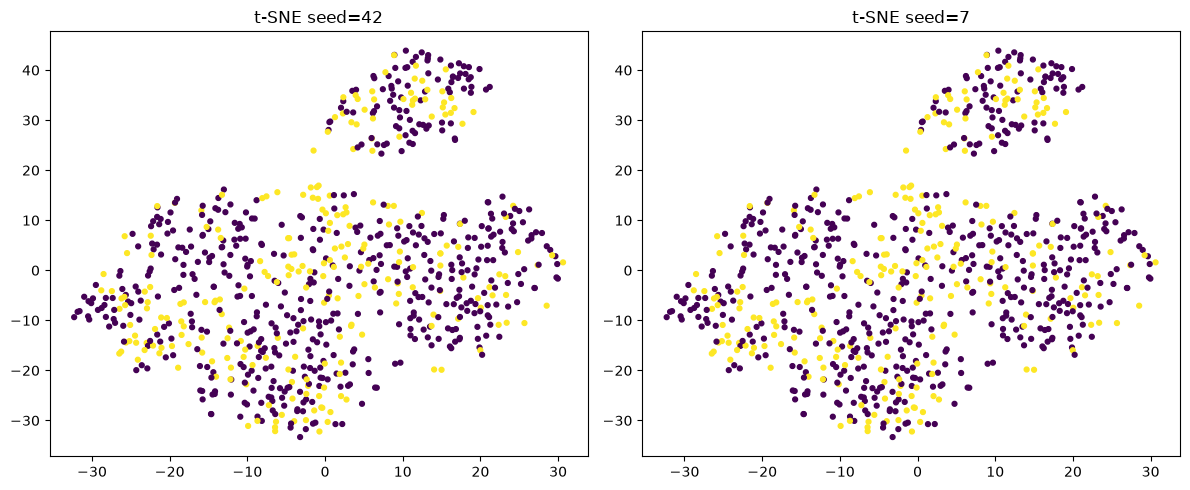

In [5]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Usamos los datos ya preprocesados (numéricos, escalados y codificados)
sample_size = min(800, X_processed_train.shape[0])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, seed in zip(axes, [42, 7]):
    emb = TSNE(n_components=2, perplexity=30, random_state=seed,
               init="pca", learning_rate="auto").fit_transform(X_processed_train)
    ax.scatter(emb[:, 0], emb[:, 1], c=ytr.values, s=12, cmap="viridis")
    ax.set_title(f"t-SNE seed={seed}")
plt.tight_layout()
plt.savefig("../reports/tsne_two_seeds.png", dpi=160)
plt.show()

In [6]:
def pareto_flags(df, score="f1_macro", cost="fit_median_s"):
    flags = []
    for _, row in df.iterrows():
        dominated = ((df[score] >= row[score]) & (df[cost] <= row[cost]) &
                     ((df[score] > row[score]) | (df[cost] < row[cost]))).any()
        flags.append(not bool(dominated))
    return flags

results["is_pareto"] = pareto_flags(results)
results.to_csv("../reports/green_ai_results.csv", index=False)
results.sort_values(["is_pareto", "f1_macro"], ascending=[False, False])

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb,is_pareto
1,svm_c1,0.736264,0.761905,1.382955,176.5800,305.427734,True
0,logistic,0.720954,0.709524,0.250068,54.1653,7.916016,True
2,svm_c10,0.726545,0.732143,1.992890,121.3018,281.099609,False
4,rf_300,0.696794,0.717857,3.165966,407.5032,3864.073242,False
5,boost,0.688150,0.676190,1.770301,56.5967,209.814453,False
3,rf_100,0.674743,0.694048,1.200619,216.4370,1315.948242,False


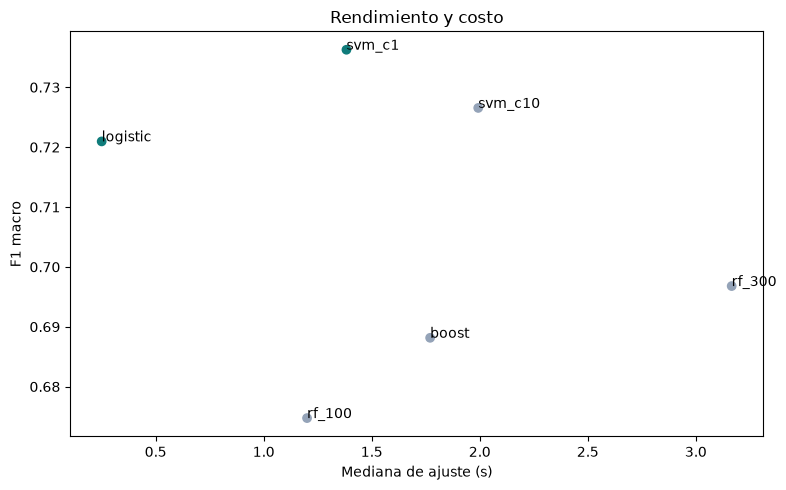

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(results.fit_median_s, results.f1_macro,
           c=results.is_pareto.map({True: "#0f7c7b", False: "#94a3b8"}))
for _, r in results.iterrows():
    ax.annotate(r.model, (r.fit_median_s, r.f1_macro))
ax.set(xlabel="Mediana de ajuste (s)", ylabel="F1 macro", title="Rendimiento y costo")
plt.tight_layout()
plt.savefig("../reports/pareto.png", dpi=160)
plt.show()

In [8]:
import platform, sys, sklearn
print("Python", sys.version)
print("Sistema", platform.platform())
print("Procesador", platform.processor())
print("scikit-learn", sklearn.__version__)

Python 3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]
Sistema Windows-11-10.0.26200-SP0
Procesador Intel64 Family 6 Model 122 Stepping 8, GenuineIntel
scikit-learn 1.9.1
